# Low-qubit VQE Benchmark

This notebook benchmarks noiseless `VQE` across the supported registry molecules whose resolved qubit count stays below the small-system threshold.

It reports:

- resolved qubit count by molecule
- Hamiltonian term count
- exact ground-state reference energy
- mean / standard deviation of final VQE energy across seeds
- mean / standard deviation of absolute error and original compute runtime

The notebook is meant to be a decision notebook, not a tutorial. It uses the packaged public helper `run_vqe_low_qubit_benchmark(...)` so the benchmark logic stays aligned with the repository API.

If cached artifacts already exist, the benchmark still prefers each run's stored `compute_runtime_s` value when available rather than the latest cache-hit wall time.

In [ ]:
from __future__ import annotations

import matplotlib.pyplot as plt
import pandas as pd
from IPython.display import display

from vqe import run_vqe_low_qubit_benchmark

MOLECULES = ["H2", "H3+", "H4"]
MAX_QUBITS = 10
SEEDS = [0, 1, 2]
ANSATZ = "UCCSD"
OPTIMIZER = "Adam"
STEPS = 75


In [14]:
benchmark = run_vqe_low_qubit_benchmark(
    molecules=MOLECULES,
    max_qubits=MAX_QUBITS,
    seeds=SEEDS,
    ansatz_name=ANSATZ,
    optimizer_name=OPTIMIZER,
    steps=STEPS,
    show=False,
    force=False
)

summary_df = pd.DataFrame(benchmark["rows"]).sort_values(
    ["num_qubits", "abs_error_mean", "runtime_mean_s", "molecule"]
)

display(
    summary_df[
        [
            "molecule",
            "num_qubits",
            "hamiltonian_terms",
            "exact_ground_energy",
            "energy_mean",
            "energy_std",
            "abs_error_mean",
            "abs_error_std",
            "runtime_mean_s",
            "runtime_std_s",
            "parameter_count",
        ]
    ].round(8)
)

print(f"Saved benchmark plot: {benchmark['plot_path']}")

if benchmark["skipped"]:
    display(pd.DataFrame(benchmark["skipped"]))



🔹 Running low-qubit VQE benchmark (max_qubits=10, ansatz=UCCSD, optimizer=Adam)

⚙️ Benchmarking H2 (4 qubits, exact=-1.13727017 Ha)
  → E = -1.13726795 ± 0.00e+00 Ha, |Δ| = 2.23e-06 ± 0.00e+00 Ha, t = 2.941 ± 0.470 s

⚙️ Benchmarking H3+ (6 qubits, exact=-1.29605528 Ha)
  → E = -1.26172871 ± 0.00e+00 Ha, |Δ| = 3.43e-02 ± 0.00e+00 Ha, t = 31.920 ± 3.228 s

⚙️ Benchmarking H4 (8 qubits, exact=-2.16638745 Ha)
  → E = -2.16629108 ± 0.00e+00 Ha, |Δ| = 9.64e-05 ± 0.00e+00 Ha, t = 256.256 ± 51.862 s
📁 Saved plot → /workspaces/Variational_Quantum_Eigensolver/images/vqe/multi_molecule/low_qubit_benchmark_UCCSD_Adam_jordan_wigner_max10q.png

✅ Low-qubit VQE benchmark complete for 3 molecule(s)


,molecule,num_qubits,hamiltonian_terms,exact_ground_energy,energy_mean,energy_std,abs_error_mean,abs_error_std,runtime_mean_s,runtime_std_s,parameter_count
0,H2,4,15,-1.137270,-1.137268,0.0,0.000002,0.0,2.941093,0.470165,3
1,H3+,6,62,-1.296055,-1.261729,0.0,0.034327,0.0,31.919543,3.227556,8
2,H4,8,185,-2.166387,-2.166291,0.0,0.000096,0.0,256.256229,51.861543,26


Saved benchmark plot: /workspaces/Variational_Quantum_Eigensolver/images/vqe/multi_molecule/low_qubit_benchmark_UCCSD_Adam_jordan_wigner_max10q.png


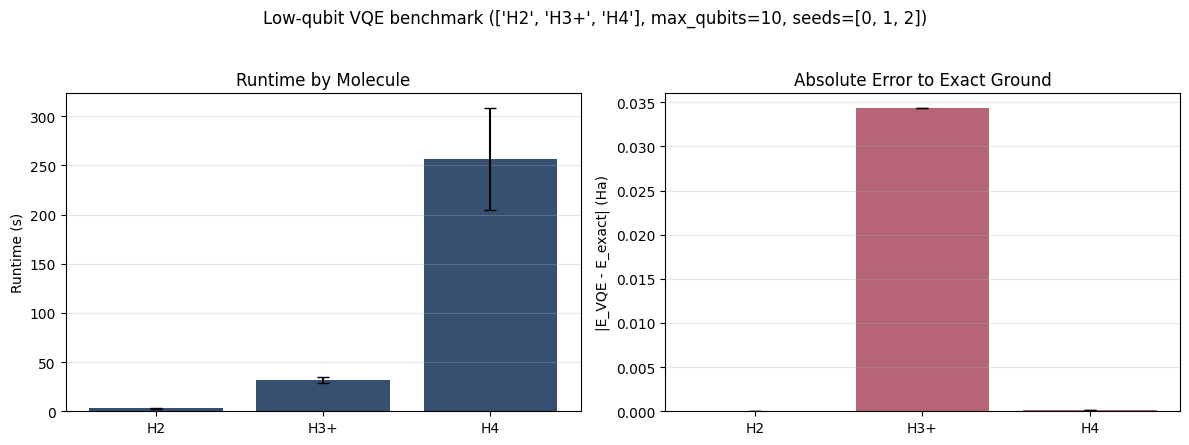

In [15]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))

axes[0].bar(summary_df["molecule"], summary_df["runtime_mean_s"], yerr=summary_df["runtime_std_s"], color="#355070", capsize=4)
axes[0].set_title("Runtime by Molecule")
axes[0].set_ylabel("Runtime (s)")
axes[0].grid(True, axis="y", alpha=0.3)

axes[1].bar(summary_df["molecule"], summary_df["abs_error_mean"], yerr=summary_df["abs_error_std"], color="#b56576", capsize=4)
axes[1].set_title("Absolute Error to Exact Ground")
axes[1].set_ylabel("|E_VQE - E_exact| (Ha)")
axes[1].grid(True, axis="y", alpha=0.3)

fig.suptitle(
    f"Low-qubit VQE benchmark ({MOLECULES}, max_qubits={MAX_QUBITS}, seeds={SEEDS})"
)
fig.tight_layout(rect=[0, 0, 1, 0.95])
plt.show()


In [16]:
focus_view = summary_df[["molecule", "num_qubits", "abs_error_mean", "runtime_mean_s"]].copy()
focus_view = focus_view.sort_values(["num_qubits", "abs_error_mean", "runtime_mean_s"])
focus_view.round(8)


,molecule,num_qubits,abs_error_mean,runtime_mean_s
0,H2,4,0.000002,2.941093
1,H3+,6,0.034327,31.919543
2,H4,8,0.000096,256.256229


## Suggested Extensions

- Repeat the benchmark with `molecules=["H2", "H3+", "H4", "H5+"]` if you want a fixed low-qubit panel regardless of future registry additions.
- Add a noisy companion notebook once you want channel-specific robustness comparisons on the same molecule set.
- Pair this notebook with `LiH` and `BeH2` notebooks when you want to show where the small-system benchmark stops being representative.